In [5]:
import os
import sys
import math
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm

# Link to the custom dataset file
sys.path.append('..')
from dataset import TimepieceDataset

# Setup compute hardware
compute_device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Active hardware: {compute_device}")

Active hardware: cuda


## 1. Custom CNN Regressor

In [6]:
# ===================== CELL 3: CNN MODEL =====================
class SimpleVisionNet(nn.Module):
    """Basic CNN architecture for regression of h, m, s coordinates."""
    def __init__(self):
        super(SimpleVisionNet, self).__init__()
        
        self.feature_extractor = nn.Sequential(
            # Block 1: 128 -> 64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 2: 64 -> 32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 3: 32 -> 16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.regressor_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 3) # Target: (hour, minute, second)
        )

    def forward(self, img_tensor):
        features = self.feature_extractor(img_tensor)
        return self.regressor_head(features)

In [7]:
# ===================== CELL 4: CNN TRAINING LOGIC =====================
def execute_cnn_training(target_dir="../datasets", max_epochs=10, b_size=32, lr_rate=0.0001):
    print(f"Hardware assigned: {compute_device}")

    # Standard vision processing
    img_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
    ])
    
    # Updated Dataset Calls
    ds_train = TimepieceDataset(base_path=target_dir, partition='train', transforms_pipeline=img_transform)
    ds_val   = TimepieceDataset(base_path=target_dir, partition='test',  transforms_pipeline=img_transform)
    
    loader_train = DataLoader(ds_train, batch_size=b_size, shuffle=True)
    loader_val   = DataLoader(ds_val,   batch_size=b_size, shuffle=False)

    cnn_model = SimpleVisionNet().to(compute_device)
    loss_function = nn.MSELoss()
    adam_optimizer = optim.Adam(cnn_model.parameters(), lr=lr_rate)

    lowest_val_loss = float('inf')
    os.makedirs('checkpoints', exist_ok=True)

    print("Initiating custom CNN training...")
    
    for current_epoch in range(max_epochs):
        cnn_model.train()
        accumulated_loss = 0.0
        
        train_progress = tqdm(
            loader_train,
            desc=f"Epoch {current_epoch + 1}/{max_epochs} [train]",
            leave=False,
        )
        for data_batch in train_progress:
            img_inputs = data_batch['digital_img'].to(compute_device)
            target_vals = data_batch['time_label'].to(compute_device) 
            
            adam_optimizer.zero_grad()
            predictions = cnn_model(img_inputs)
            
            batch_loss = loss_function(predictions, target_vals)
            batch_loss.backward()
            adam_optimizer.step()
            
            accumulated_loss += batch_loss.item()
            train_progress.set_postfix(loss=f"{batch_loss.item():.4f}")

        mean_train_loss = accumulated_loss / len(loader_train)

        # Validation Phase
        cnn_model.eval()
        accumulated_val_loss = 0.0
        with torch.no_grad():
            val_progress = tqdm(
                loader_val,
                desc=f"Epoch {current_epoch + 1}/{max_epochs} [val]",
                leave=False,
            )
            for val_batch in val_progress:
                val_imgs = val_batch['digital_img'].to(compute_device)
                val_targets = val_batch['time_label'].to(compute_device)
                val_preds = cnn_model(val_imgs)
                val_loss = loss_function(val_preds, val_targets)
                accumulated_val_loss += val_loss.item()
                val_progress.set_postfix(loss=f"{val_loss.item():.4f}")
        
        mean_val_loss = accumulated_val_loss / len(loader_val)
        
        print(f"Epoch [{current_epoch+1}/{max_epochs}] | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f}")

        if mean_val_loss < lowest_val_loss:
            lowest_val_loss = mean_val_loss
            torch.save(cnn_model.state_dict(), "checkpoints/digital_reader_best.pth")
            print("  --> Checkpoint saved!")

In [8]:
# ===================== CELL 5: RUN CNN =====================
if __name__ == "__main__":
    execute_cnn_training(target_dir="../datasets", max_epochs=40)

Hardware assigned: cuda
Initiating custom CNN training...


Epoch 1/40 [train]:   0%|          | 0/407 [00:00<?, ?it/s]

Epoch 1/40 [val]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch [1/40] | Train Loss: 0.0684 | Val Loss: 0.0090
  --> Checkpoint saved!


Epoch 2/40 [train]:   0%|          | 0/407 [00:00<?, ?it/s]

...

Epoch 39/40 [val]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch [39/40] | Train Loss: 0.0034 | Val Loss: 0.0005


Epoch 40/40 [train]:   0%|          | 0/407 [00:00<?, ?it/s]

Epoch 40/40 [val]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch [40/40] | Train Loss: 0.0034 | Val Loss: 0.0003


In [9]:
# ===================== CELL 6: CNN EVALUATION =====================
def scale_to_hms(norm_tensor):
    """Denormalizes the 0-1 tensor back to human-readable time."""
    val_h = int(norm_tensor[0].item() * 23)
    val_m = int(norm_tensor[1].item() * 59)
    val_s = int(norm_tensor[2].item() * 59)
    return f"{val_h:02d}:{val_m:02d}:{val_s:02d}"

def test_cnn_performance():
    img_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    val_ds = TimepieceDataset(base_path="../datasets", partition='test', transforms_pipeline=img_transform)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=True)

    eval_model = SimpleVisionNet().to(compute_device)
    try:
        eval_model.load_state_dict(torch.load("checkpoints/digital_reader_best.pth", map_location=compute_device))
        print("Model weights loaded successfully.")
    except FileNotFoundError:
        print("Failed to locate model checkpoint.")
        return

    eval_model.eval()

    print("\n--- Model Evaluation (Basic CNN) ---")
    print(f"{'Target':<10} | {'Output':<10} | {'MSE Error'}")
    print("-" * 35)

    with torch.no_grad():
        for step, data_batch in enumerate(val_loader):
            if step >= 10: break
            
            pixels = data_batch['digital_img'].to(compute_device)
            ground_truth = data_batch['time_label'].to(compute_device)
            
            network_out = eval_model(pixels)
            
            str_actual = scale_to_hms(ground_truth[0])
            str_pred = scale_to_hms(network_out[0])
            
            step_loss = torch.nn.functional.mse_loss(network_out, ground_truth).item()
            print(f"{str_actual:<10} | {str_pred:<10} | {step_loss:.4f}")

if __name__ == "__main__":
    test_cnn_performance()

Model weights loaded successfully.

--- Model Evaluation (Basic CNN) ---
Target     | Output     | MSE Error
-----------------------------------
17:15:22   | 35:11:30   | 0.1917
17:13:57   | 38:20:123  | 0.6877
11:42:47   | 21:82:100  | 0.4835
08:33:47   | 08:49:71   | 0.0820
05:26:23   | 11:34:37   | 0.0423
17:11:57   | 38:05:123  | 0.7133
18:02:30   | 30:00:46   | 0.1108
04:26:04   | 14:37:14   | 0.0858
06:59:13   | 16:101:23  | 0.2375
01:45:15   | 00:75:21   | 0.0923


## ResNet Transfer Learning (Regression)

In [10]:
# ===================== CELL 8: RESNET MODEL =====================
class VisionResNetRegressor(nn.Module):
    def __init__(self):
        super(VisionResNetRegressor, self).__init__()
        
        # Pull standard pre-trained ResNet18
        self.core_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_dimensions = self.core_model.fc.in_features 
        
        # Overwrite the final classification head for our 3-variable regression
        self.core_model.fc = nn.Sequential(
            nn.Linear(in_dimensions, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3) 
        )

    def forward(self, img_tensor):
        return self.core_model(img_tensor)

In [16]:
def execute_resnet_training(target_dir="../datasets", max_epochs=10, b_size=32, lr_rate=0.0001):
    resnet_transforms = transforms.Compose([
        transforms.Resize((224, 224)), 
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    ds_train = TimepieceDataset(base_path=target_dir, partition='train', transforms_pipeline=resnet_transforms)
    ds_val   = TimepieceDataset(base_path=target_dir, partition='test',  transforms_pipeline=resnet_transforms)
    
    loader_train = DataLoader(ds_train, batch_size=b_size, shuffle=True)
    loader_val   = DataLoader(ds_val,   batch_size=b_size, shuffle=False)

    resnet_model = VisionResNetRegressor().to(compute_device)
    loss_function = nn.MSELoss()
    adam_optimizer = optim.Adam(resnet_model.parameters(), lr=lr_rate) 

    lowest_val_loss = float('inf')
    os.makedirs('checkpoints', exist_ok=True)

    print("Initiating ResNet regression training...")
    
    for current_epoch in range(max_epochs):
        resnet_model.train()
        accumulated_loss = 0.0
        
        for data_batch in loader_train:
            img_inputs = data_batch['digital_img'].to(compute_device)
            target_vals = data_batch['time_label'].to(compute_device)
            
            predictions = resnet_model(img_inputs)
            batch_loss = loss_function(predictions, target_vals)
            
            adam_optimizer.zero_grad()
            batch_loss.backward()
            adam_optimizer.step()
            
            accumulated_loss += batch_loss.item()

        mean_train_loss = accumulated_loss / len(loader_train)

        # Validation logic
        resnet_model.eval()
        accumulated_val_loss = 0.0
        with torch.no_grad():
            for val_batch in loader_val:
                val_imgs = val_batch['digital_img'].to(compute_device)
                val_targets = val_batch['time_label'].to(compute_device)
                val_preds = resnet_model(val_imgs)
                accumulated_val_loss += loss_function(val_preds, val_targets).item()
        
        mean_val_loss = accumulated_val_loss / len(loader_val)
        print(f"Epoch [{current_epoch+1}/{max_epochs}] | Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f}")

        if mean_val_loss < lowest_val_loss:
            lowest_val_loss = mean_val_loss
            torch.save(resnet_model.state_dict(), "checkpoints/digital_resnet_best.pth")
            print("  --> Saved ResNet weights!")

if __name__ == "__main__":
    execute_resnet_training(target_dir="../datasets", max_epochs=40)

Initiating ResNet regression training...
Epoch [1/40] | Train Loss: 0.0212 | Val Loss: 0.0025
  --> Saved ResNet weights!
Epoch [2/40] | Train Loss: 0.0089 | Val Loss: 0.0012
  --> Saved ResNet weights!
Epoch [3/40] | Train Loss: 0.0070 | Val Loss: 0.0014
Epoch [4/40] | Train Loss: 0.0060 | Val Loss: 0.0008
  --> Saved ResNet weights!


Initiating ResNet regression training...
Epoch [1/40] | Train Loss: 0.0212 | Val Loss: 0.0025
  --> Saved ResNet weights!
Epoch [2/40] | Train Loss: 0.0089 | Val Loss: 0.0012
  --> Saved ResNet weights!
Epoch [3/40] | Train Loss: 0.0070 | Val Loss: 0.0014
Epoch [4/40] | Train Loss: 0.0060 | Val Loss: 0.0008
  --> Saved ResNet weights!


KeyboardInterrupt: 

In [ ]:
# ===================== CELL 10: RESNET EVALUATION =====================
def test_resnet_performance():
    resnet_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    val_ds = TimepieceDataset(base_path="../datasets", partition='test', transforms_pipeline=resnet_transforms)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=True)

    eval_model = VisionResNetRegressor().to(compute_device)
    
    try:
        eval_model.load_state_dict(torch.load("checkpoints/digital_resnet_best.pth", map_location=compute_device))
        print("ResNet weights loaded.")
    except FileNotFoundError:
        print("Failed to locate ResNet checkpoint.")
        return

    eval_model.eval()

    print("\n--- Model Evaluation (ResNet Regressor) ---")
    print(f"{'Target':<10} | {'Output':<10} | {'MSE Error'}")
    print("-" * 35)

    def force_hms(norm_tensor):
        # Clamp to bounds to prevent edge-case math errors
        bounded_tensor = torch.clamp(norm_tensor, 0, 1) 
        val_h = int(bounded_tensor[0].item() * 23)
        val_m = int(bounded_tensor[1].item() * 59)
        val_s = int(bounded_tensor[2].item() * 59)
        return f"{val_h:02d}:{val_m:02d}:{val_s:02d}"

    with torch.no_grad():
        for step, data_batch in enumerate(val_loader):
            if step >= 10: break
            
            pixels = data_batch['digital_img'].to(compute_device)
            ground_truth = data_batch['time_label'].to(compute_device)
            
            network_out = eval_model(pixels)
            
            str_actual = force_hms(ground_truth[0])
            str_pred = force_hms(network_out[0])
            
            step_loss = torch.nn.functional.mse_loss(network_out, ground_truth).item()
            print(f"{str_actual:<10} | {str_pred:<10} | {step_loss:.6f}")

if __name__ == "__main__":
    test_resnet_performance()

C:\Users\ofekh\AppData\Local\Temp\ipykernel_21996\1813765914.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eval_model.load_state_dict(torch.load("checkpoints/digital_

ResNet weights loaded.

--- Model Evaluation (ResNet Regressor) ---
Target     | Output     | MSE Error
-----------------------------------
23:55:35   | 20:36:37   | 0.037552
00:42:48   | 07:21:33   | 0.102306
08:10:53   | 07:24:33   | 0.059849
08:21:10   | 04:37:16   | 0.036453
02:38:05   | 05:32:32   | 0.078852
18:35:45   | 13:33:35   | 0.027433
11:33:05   | 12:33:20   | 0.023975
22:57:06   | 10:27:43   | 0.294904
05:35:40   | 05:28:38   | 0.003893
08:05:21   | 04:27:45   | 0.115922


In [17]:
# ===================== CELL 12: CLASSIFIER MODEL =====================
class MultiBranchTimeClassifier(nn.Module):
    """
    Transforms the continuous time problem into discrete buckets.
    """
    def __init__(self):
        super().__init__()
        core = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        features_dim = core.fc.in_features          
        core.fc = nn.Identity()             
        self.feature_extractor = core

        self.shared_mlp = nn.Sequential(
            nn.Linear(features_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        self.branch_hour = nn.Linear(256, 24)
        self.branch_min  = nn.Linear(256, 60)
        self.branch_sec  = nn.Linear(256, 60)

    def forward(self, img_tensor):
        extracted = self.feature_extractor(img_tensor)
        hidden = self.shared_mlp(extracted)
        return self.branch_hour(hidden), self.branch_min(hidden), self.branch_sec(hidden)

    def infer_time(self, img_tensor):
        logit_h, logit_m, logit_s = self.forward(img_tensor)
        pred_h = logit_h.argmax(dim=1)
        pred_m = logit_m.argmax(dim=1)
        pred_s = logit_s.argmax(dim=1)
        return pred_h, pred_m, pred_s

In [21]:
# ===================== CELL 13: CLASSIFIER TRAINING LOGIC =====================
def execute_classifier_training(target_dir='../datasets', max_epochs=10, b_size=32, lr_rate=1e-4):
    stable_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    ds_train = TimepieceDataset(base_path=target_dir, partition='train', transforms_pipeline=stable_transform)
    ds_val   = TimepieceDataset(base_path=target_dir, partition='test',  transforms_pipeline=stable_transform)
    
    loader_train = DataLoader(ds_train, batch_size=b_size, shuffle=True,  num_workers=0)
    loader_val   = DataLoader(ds_val,   batch_size=b_size, shuffle=False, num_workers=0)

    classifier_model = MultiBranchTimeClassifier().to(compute_device)
    loss_function = nn.CrossEntropyLoss(label_smoothing=0.05)
    adamw_optim = optim.AdamW(classifier_model.parameters(), lr=lr_rate, weight_decay=1e-4)
    
    def calculate_lr(epoch_idx):
        if max_epochs <= 5:
            return 1.0
        if epoch_idx < 5:
            return (epoch_idx + 1) / 5
        progression = (epoch_idx - 5) / (max_epochs - 5)
        return 0.5 * (1 + math.cos(math.pi * progression))
    
    lr_scheduler = optim.lr_scheduler.LambdaLR(adamw_optim, calculate_lr)

    checkpoint_path = 'checkpoints/digital_classifier_best.pth'
    os.makedirs('checkpoints', exist_ok=True)
    highest_accuracy = 0.0

    for epoch in range(max_epochs):
        classifier_model.train()
        accumulated_loss = 0.0
        
        for data_batch in loader_train:
            img_inputs = data_batch['digital_img'].to(compute_device)
            raw_labels = data_batch['original_time'].to(compute_device)
            
            target_h, target_m, target_s = raw_labels[:,0], raw_labels[:,1], raw_labels[:,2]

            pred_h, pred_m, pred_s = classifier_model(img_inputs)
            
            batch_loss = (loss_function(pred_h, target_h) +
                          2.0 * loss_function(pred_m, target_m) +
                          2.0 * loss_function(pred_s, target_s))

            adamw_optim.zero_grad()
            batch_loss.backward()
            adamw_optim.step()
            accumulated_loss += batch_loss.item()

        lr_scheduler.step()
        active_lr = adamw_optim.param_groups[0]['lr']

        classifier_model.eval()
        hits_h = hits_m = hits_s = perfect_matches = total_samples = 0
        
        with torch.no_grad():
            for val_batch in loader_val:
                val_imgs = val_batch['digital_img'].to(compute_device)
                val_labels = val_batch['original_time'].to(compute_device)
                
                target_h, target_m, target_s = val_labels[:,0], val_labels[:,1], val_labels[:,2]
                out_h, out_m, out_s = classifier_model.infer_time(val_imgs)
                
                hits_h += (out_h == target_h).sum().item()
                hits_m += (out_m == target_m).sum().item()
                hits_s += (out_s == target_s).sum().item()
                perfect_matches += ((out_h == target_h) & (out_m == target_m) & (out_s == target_s)).sum().item()
                total_samples += val_imgs.size(0)

        overall_accuracy = 100 * perfect_matches / total_samples
        
        print(f"Epoch [{epoch+1:>3}/{max_epochs}] | "
              f"Loss: {accumulated_loss/len(loader_train):.4f} | LR: {active_lr:.5f} | "
              f"H: {100*hits_h/total_samples:.0f}% | "
              f"M: {100*hits_m/total_samples:.0f}% | "
              f"S: {100*hits_s/total_samples:.0f}% | "
              f"Total Acc: {overall_accuracy:.1f}%")

        if epoch == 0 or overall_accuracy > highest_accuracy:
            highest_accuracy = overall_accuracy
            torch.save(classifier_model.state_dict(), checkpoint_path)
            print("Saved checkpoint at:", checkpoint_path)

In [23]:
# ===================== CELL 14: CLASSIFIER EVALUATION =====================
def test_classifier_performance(target_dir='../datasets'):
    eval_pipeline = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    val_ds = TimepieceDataset(base_path=target_dir, partition='test', transforms_pipeline=eval_pipeline)
    val_loader = DataLoader(val_ds, batch_size=1, shuffle=True, num_workers=0)

    eval_model = MultiBranchTimeClassifier().to(compute_device)
    eval_model.load_state_dict(torch.load('checkpoints/digital_classifier_best.pth', map_location=compute_device))
    eval_model.eval()

    print(f"\n{'Target':<12} {'Output':<12} {'Status'}")
    print("-" * 40)

    mistake_log = []
    
    with torch.no_grad():
        for step, data_batch in enumerate(val_loader):
            if step >= 20: break
            
            pixels = data_batch['digital_img'].to(compute_device)
            target_h, target_m, target_s = (data_batch['original_time'][:, j].item() for j in range(3))

            out_h, out_m, out_s = eval_model.infer_time(pixels)
            pred_h, pred_m, pred_s = out_h.item(), out_m.item(), out_s.item()

            str_actual = f"{target_h:02d}:{target_m:02d}:{target_s:02d}"
            str_pred   = f"{pred_h:02d}:{pred_m:02d}:{pred_s:02d}"
            
            is_correct = "Match" if str_actual == str_pred else "Miss"
            print(f"{str_actual:<12} {str_pred:<12} {is_correct}")

            if is_correct == "Miss" and len(mistake_log) == 0:
                mistake_log.append((pixels.cpu(), str_actual, str_pred))

    # Render out the first failure to visually debug
    if mistake_log:
        tensor_img, actual_val, pred_val = mistake_log[0]
        plt.figure(figsize=(4, 4))
        plt.imshow(tensor_img[0].permute(1, 2, 0).clamp(0, 1))
        plt.title(f"Missed: True={actual_val} | Pred={pred_val}", color='red')
        plt.axis('off')
        plt.tight_layout()
        print("\nDisplaying first error encountered:")
        plt.show()

In [22]:
# ===================== CELL 15: RUN CLASSIFIER =====================
if __name__ == "__main__":
    execute_classifier_training(target_dir='../datasets', max_epochs=1)

Epoch [  1/1] | Loss: 10.7185 | LR: 0.00010 | H: 85% | M: 86% | S: 89% | Total Acc: 62.4%
Saved checkpoint at: checkpoints/digital_classifier_best.pth



Target       Output       Status
----------------------------------------
00:58:43     00:57:38     Miss
12:12:24     06:55:08     Miss
09:14:34     00:57:38     Miss
16:44:32     00:57:38     Miss
19:54:31     13:09:38     Miss
01:44:18     06:05:38     Miss
02:00:52     16:09:36     Miss
14:29:50     16:09:56     Miss
18:34:43     06:11:17     Miss
01:53:23     13:09:32     Miss
00:52:21     16:09:36     Miss
05:32:39     00:05:38     Miss
04:22:07     06:55:08     Miss
18:37:14     00:05:38     Miss
23:28:24     06:55:17     Miss
16:17:27     00:05:38     Miss
17:39:57     00:05:38     Miss
12:06:42     00:57:38     Miss
20:09:21     00:57:38     Miss
18:24:15     00:05:38     Miss

Displaying first error encountered:


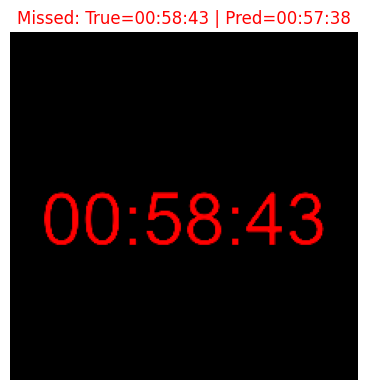

In [24]:
# ===================== CELL 16: RUN CLASSIFIER EVALUATION =====================
if __name__ == "__main__":
    test_classifier_performance(target_dir='../datasets')